# Gnomad frequency visualization for meSNPs

## Load libraries

In [1]:
library(readr)
library(ggplot2)
library(ggpubr)

## Load data

Load dataframe with gnomad frequencies for meSNPs

In [ ]:
dat <- read.csv("meSNPs_with_gnomad_freq.csv")

,locus,alleles,rs,chr_name,chrom_start,ref,alt,snp,type,global_adj,⋯,mid_adj,remaining_adj,ami_adj,asj_adj,afr_adj,eas_adj,sas_adj,amr_adj,grpmax_freq,grpmax_ancestry
,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,chr1:100803863,"[""A"",""G""]",rs17123381,1,100803863,A,G,SNP_A-1881799,trans,0.01874319,⋯,0.003401361,0.015610218,0,0.0000000000,0.06301732,0.002312139,0.0180572852,0.004902602,0.063017,afr
2,chr1:101639888,"[""T"",""C""]",rs12058603,1,101639888,T,C,SNP_A-8676380,trans,0.02305046,⋯,0.003401361,0.017013233,0,0.0034602076,0.07937157,0.000000000,0.0000000000,0.008372580,0.079372,afr
3,chr1:106757252,"[""T"",""C""]",rs17017598,1,106757252,T,C,SNP_A-8454487,trans,0.01595325,⋯,0.000000000,0.007109005,0,0.0000000000,0.05591947,0.000000000,0.0002070393,0.005437631,0.055919,afr
4,chr1:110978190,"[""G"",""A""]",rs1780558,1,110978190,G,A,SNP_A-8310135,trans,0.02739636,⋯,0.003401361,0.019848771,0,0.0000000000,0.09536430,0.000000000,0.0004142502,0.008958933,0.095364,afr
5,chr1:112967635,"[""T"",""C""]",rs11805071,1,112967635,T,C,SNP_A-8628754,trans,0.01583600,⋯,0.010204082,0.017502365,0,0.0000000000,0.05418292,0.000000000,0.0002072968,0.006741720,0.054183,afr
6,chr1:11392234,"[""G"",""A""]",rs4329522,1,11392234,G,A,SNP_A-2140442,trans,0.01715371,⋯,0.010204082,0.017992424,0,0.0005763689,0.04858368,0.048337200,0.0332088003,0.007849294,0.048584,afr


## Prepare data for visualization

Subset data

In [ ]:
sub <- dat[,c('snp','rs','global_adj','afr_adj','nfe_adj')] # Select columns of interest (Illumina SNP and rs id, as well as population-specific and global AFs)

,snp,rs,global_adj,afr_adj,nfe_adj,Significant,deltaMAF,type
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
1,SNP_A-1782472,rs7564790,0.01794572,0.062496986,0.0004561910,Significant_TRUE,0.062040795,trans
2,SNP_A-1783883,rs16842347,0.01526171,0.051977102,0.0003821843,Significant_TRUE,0.051594918,trans
3,SNP_A-1784210,rs6944190,0.01926694,0.067533031,0.0002499559,Significant_TRUE,0.067283075,trans
4,SNP_A-1784500,rs2292732,0.00563532,0.001275326,0.0002499706,Significant_FALSE,0.001025355,trans
5,SNP_A-1785586,rs2363286,0.11377454,0.049586379,0.1546922330,Significant_TRUE,0.105105854,cis
6,SNP_A-1786631,rs17134038,0.03253143,0.113887149,0.0003527959,Significant_TRUE,0.113534353,trans


## Population-specific gnomad AF violin plots

Process df to prepare it for density plotting

In [ ]:
library(dplyr)  
library(tidyr)

df_long <- bind_rows(  
  sub %>%  
    select(rs, snp) %>%  
    mutate(AF = sub$afr_adj, pop = "AFR"),  
  sub %>%  
    select(rs, type) %>%  
    mutate(AF = sub$nfe_adj, pop = "EUR")
)  

,rs,type,deltaMAF,AF,pop
,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,rs7564790,trans,0.062040795,0.062496986,AFR
2,rs16842347,trans,0.051594918,0.051977102,AFR
3,rs6944190,trans,0.067283075,0.067533031,AFR
4,rs2292732,trans,0.001025355,0.001275326,AFR
5,rs2363286,cis,0.105105854,0.049586379,AFR
6,rs17134038,trans,0.113534353,0.113887149,AFR


Create scatterplot showing global & local AF for SNPs

In [14]:
my_colors <- c("orange","royalblue")

In [28]:
summary(df_long$AF[df_long$pop == "AFR"])
summary(df_long$AF[df_long$pop == "EUR"])

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0000242 0.0479790 0.0626084 0.0675539 0.0791451 0.4756062 

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0000000 0.0001911 0.0003088 0.0107218 0.0005735 0.5165666 

Warning message:
“Ignoring unknown parameters: width, fatten”


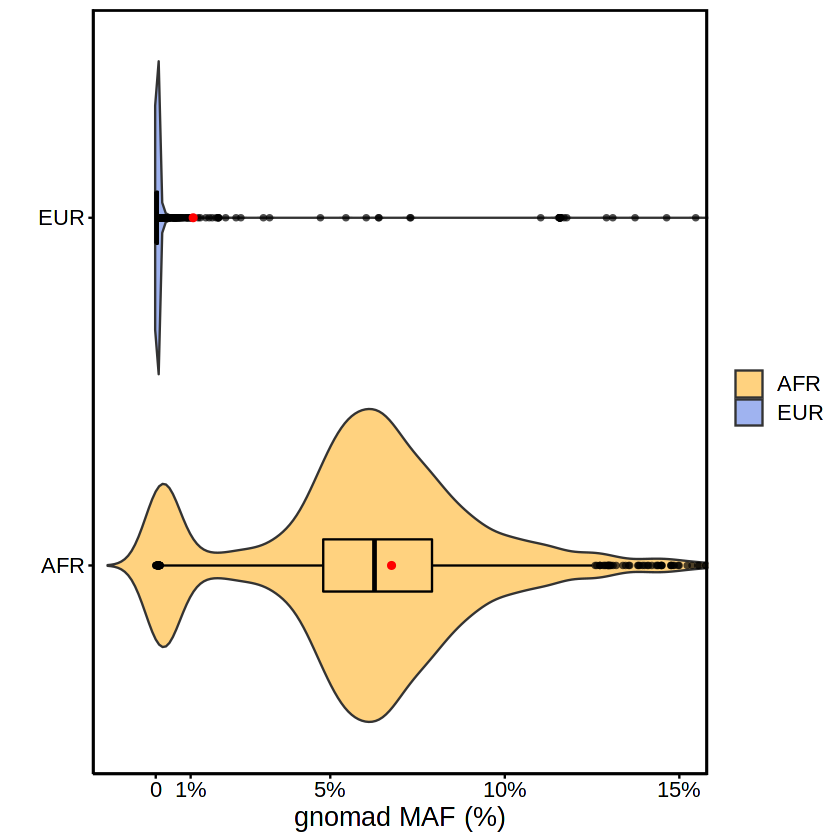

In [60]:
p0 <- ggplot(data = df_long, aes(x = pop, y = 100*AF)) +  
  geom_violin(alpha = 0.5, aes(fill = pop), scale = "width", trim = FALSE) +  
  geom_boxplot(width = 0.15, outlier.shape = 16, outlier.size = 1.5,  
               outlier.alpha = 0.7, color = "black", fill = NA) +  
  stat_summary(fun = mean, geom = "point", width = 0.15,  
               fatten = 1.5, color = "red", fill = "black") +  
  theme(legend.position = "right",  
        text = element_text(size = 16),  
        plot.title = element_text(size = 16, face = "bold"),  
        axis.title.y = element_text(size = 16),  
        axis.title.x = element_text(size = 16),  
        axis.text.x = element_text(color = "black"),  
        axis.text.y = element_text(color = "black"),  
        panel.background = element_blank(),  
        axis.line = element_line(colour = "black"),  
        axis.ticks = element_line(color = "black"),  
        panel.border = element_rect(colour = "black", fill = NA, size = 1),  
        legend.title = element_blank(),  
        legend.key = element_blank(),  
        strip.text.y = element_text(angle = 0)) +  
      scale_fill_manual(values = my_colors)+
    xlab("")+
    ylab("gnomad MAF (%)")+
    scale_y_continuous(breaks = c(0,1, 5, 10, 15),
                       labels = c("0", "1%", "5%", "10%","15%"))+
    coord_flip(ylim = c(-1, 15))

p0  

Save plot

In [ ]:
ggsave("popAF_violins_anc-meSNPs_1pcnt.jpeg", width = 13, height = 10, device='jpeg', dpi=700,units = c("cm"))

Same code to be used for visualization of control permutation analysis meSNPs, 